In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
from torchvision.models import alexnet
import torchvision.transforms as transforms

import math
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

import time

In [3]:
# --- Core Computational Utilities ---

def compute_spectral_norm(matrix):
    """
    Computes the spectral norm of a matrix.
    """
    
    return torch.linalg.matrix_norm(matrix, ord=2)

In [4]:
def compute_l21_norm(matrix):
    """
    Computes the L(2,1) norm of a matrix: L2 norm of columns, then L1 of the result.
    """
    return torch.sum(torch.linalg.norm(matrix, ord=2, dim=0))

In [5]:
# --- Main Calculation Engine ---

def compute_spectral_complexity(model: nn.Module):
    """
    Computes the spectral complexity R_A for a given PyTorch model.
    """
    product_terms = list()
    summation_terms = list()
    
    device = next(model.parameters()).device

    max_layer_time = 0
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            print(f"Processing layer: {name} of type {type(module).__name__}")

            A_i = module.weight.data
            rho_i = 1.0  # Lipschitz constant for ReLU is 1
            
            start_time = time.perf_counter()

            if A_i.dim() == 4:
                A_i = A_i.view(A_i.size(0), -1)
            
            # 1. Compute spectral norm and product term
            s_i = compute_spectral_norm(A_i)
            
            
            
            # 2. Construct the reference matrix M_i
            M_i = torch.zeros_like(A_i)
            
            # 3. Compute the deviation term for the summation
            # Formula requires ||A_i^T - M_i^T||_{2,1}
            deviation_matrix_T = A_i.T - M_i.T
            deviation_norm = compute_l21_norm(deviation_matrix_T)
            

            # Add a small epsilon to avoid division by zero if spectral norm is 0
            # sum_term = (deviation_norm**(2/3)) / ((s_i + 1e-12)**(2/3))
            sum_term = (deviation_norm / s_i)**(2/3)
            end_time = time.perf_counter()

            max_layer_time = max(max_layer_time, end_time - start_time)
            # sum_term = (deviation_norm / s_i)**(2/3)
            summation_terms.append(sum_term)
            product_terms.append(rho_i * s_i)

    # Calculate the final components
    # Product term: prod(rho_i * ||A_i||_sigma)
    total_product = torch.prod(torch.stack(product_terms))
    
    # Summation term: (sum(...))^(3/2)
    total_sum = torch.sum(torch.stack(summation_terms))
    final_sum_term = total_sum**(3/2)
    
    # Final Spectral Complexity R_A
    R_A = total_product * final_sum_term

    print(f"Maximum Computation Time for Layer: {max_layer_time:.4f}s")
    
    return R_A, total_product, final_sum_term

In [6]:
def compute_gamma_distribution(model_path, train = False, subset_size = None):
    print("Loading pretrained VGG11 model...")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = VGG11_Narrow().to(device)
    
    model.load_state_dict(torch.load(model_path, map_location=torch.device(device)))
        
    # Set the model to evaluation mode
    model.eval()
        
    # Compute the spectral complexity
    print("\nComputing spectral complexity...")
    start_time = time.perf_counter()
    spectral_complexity, product_component, sum_component = compute_spectral_complexity(model)
    end_time = time.perf_counter()
    print(f"Total Computation Time: {end_time - start_time:.4f}s")
        
    print("\n--- Results ---")
    print(f"Product Component (Lipschitz-like term): {product_component.item():.4e}")
    print(f"Summation Component (Structural Deviation term): {sum_component.item():.4e}")
    print(f"Total Spectral Complexity (R_A): {spectral_complexity.item():.4e}")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # CIFAR-10 mean/std
    ])
    testset = torchvision.datasets.CIFAR10(root='./data', train=train, download=True, transform=transform)

    if subset_size is not None:
        total_size = len(testset)
        print(f"Testset size is: {total_size}")
        if subset_size < 1 and subset_size > 0:
            subset_size = int(subset_size * total_size)
        elif subset_size <= 0:
            raise ValueError("Sorry, negative numbers as subset_size are not allowed")
        else:
            subset_size = int(subset_size)
        remainder_size = total_size - subset_size
        
        # Randomly split the dataset
        generator = torch.Generator().manual_seed(42)
        testset, _ = torch.utils.data.random_split(testset, [subset_size, remainder_size], generator=generator)
        
    testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

    num_samples = len(testset)
    data_l2_norm = 0
    
    diffs = []
    
    with torch.no_grad():
        pbar = tqdm(testloader, desc=f"Eval: ")
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            # 1. Get the score corresponding to the target class
            # We use torch.arange to index the rows, and targets to index the columns
            batch_indices = torch.arange(inputs.size(0)).to(device)
            target_scores = outputs[batch_indices, targets]
            
            # 2. Find the max of non-target classes
            # Create a clone so we don't modify the original outputs
            outputs_without_target = outputs.clone()
            
            # Set the target indices to -infinity so they are never selected as max
            outputs_without_target[batch_indices, targets] = -float('inf')
            
            # Now taking the max gives us the highest score among the "wrong" classes
            max_others = torch.max(outputs_without_target, dim=1).values
            
            # 3. Calculate difference (Target - Max(Others))
            diffs.extend((target_scores - max_others).cpu().numpy())
            data_l2_norm += torch.sum(inputs**2)

    normal_diffs = np.array(diffs)/(spectral_complexity.item() * (torch.sqrt(data_l2_norm).item() / num_samples))

    return normal_diffs

    # return np.array(diffs)

In [8]:
overfit_train = compute_gamma_distribution("ckpt_vgg11_cifar10_overfit/epoch_1000.pth", True)
overfit_test = compute_gamma_distribution("ckpt_vgg11_cifar10_overfit/epoch_1000.pth", False)

Loading pretrained VGG11 model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d
Processing layer: features.4 of type Conv2d
Processing layer: features.8 of type Conv2d
Processing layer: features.11 of type Conv2d
Processing layer: features.15 of type Conv2d
Processing layer: features.18 of type Conv2d
Processing layer: features.22 of type Conv2d
Processing layer: features.25 of type Conv2d
Processing layer: classifier.0 of type Linear
Processing layer: classifier.3 of type Linear
Processing layer: classifier.6 of type Linear
Maximum Computation Time for Layer: 0.1052s
Total Computation Time: 0.2493s

--- Results ---
Product Component (Lipschitz-like term): 4.6059e+00
Summation Component (Structural Deviation term): 2.5395e+03
Total Spectral Complexity (R_A): 1.1697e+04


Eval: 100%|██████████| 391/391 [00:29<00:00, 13.20it/s]


Loading pretrained VGG11 model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d
Processing layer: features.4 of type Conv2d
Processing layer: features.8 of type Conv2d
Processing layer: features.11 of type Conv2d
Processing layer: features.15 of type Conv2d
Processing layer: features.18 of type Conv2d
Processing layer: features.22 of type Conv2d
Processing layer: features.25 of type Conv2d
Processing layer: classifier.0 of type Linear
Processing layer: classifier.3 of type Linear
Processing layer: classifier.6 of type Linear
Maximum Computation Time for Layer: 0.1018s
Total Computation Time: 0.1250s

--- Results ---
Product Component (Lipschitz-like term): 4.6059e+00
Summation Component (Structural Deviation term): 2.5395e+03
Total Spectral Complexity (R_A): 1.1697e+04


Eval: 100%|██████████| 79/79 [00:06<00:00, 12.96it/s]


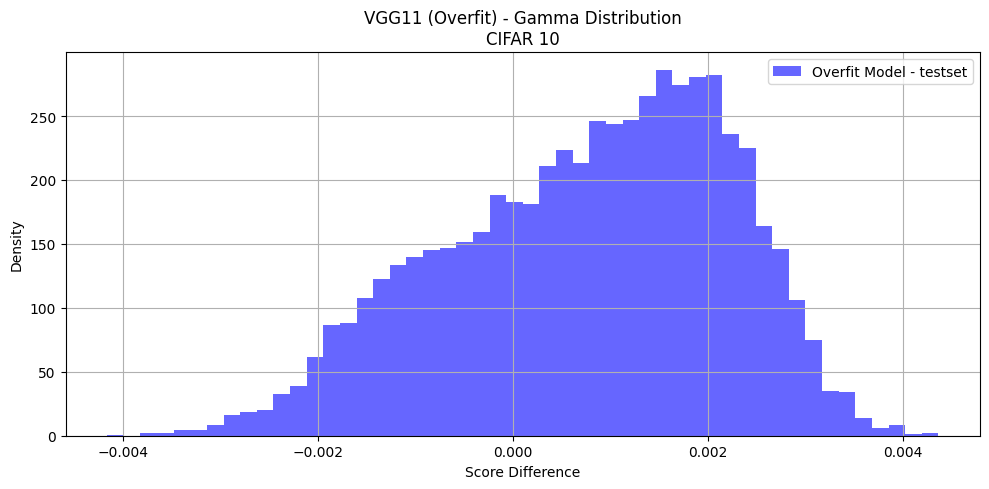

In [9]:
plt.figure(figsize=(10, 5))
# plt.hist(underfit, bins=50, alpha=0.6, label="Underfit Model", color="green", density=True)
plt.hist(overfit_test, bins=50, alpha=0.6, label="Overfit Model - testset", color="blue", density=True)
# plt.hist(overfit, bins=50, alpha=0.6, label="Overfit Model", color="orange", density=True)
plt.xlabel("Score Difference")
plt.ylabel("Density")
plt.title(f"VGG11 (Overfit) - Gamma Distribution\nCIFAR 10")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig("gamma_hist_ResNet18_cifar10.png")
plt.show()

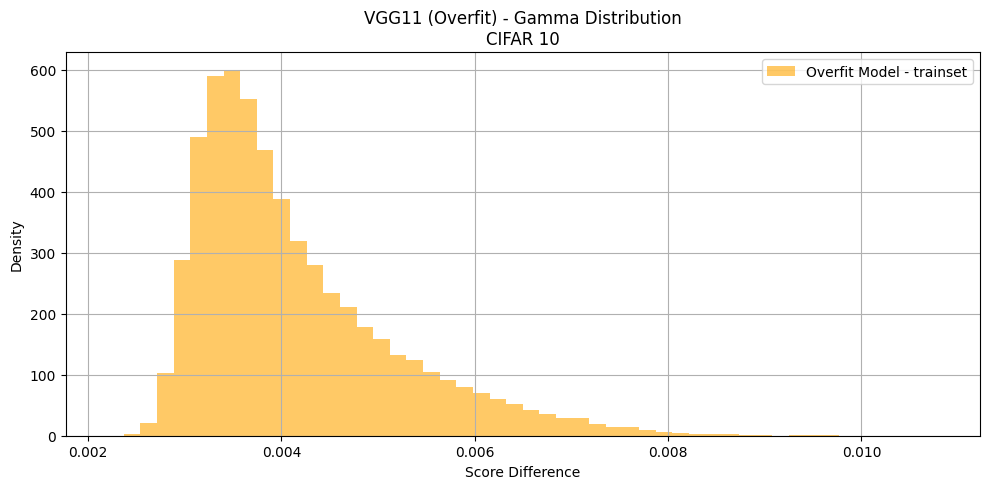

In [10]:
plt.figure(figsize=(10, 5))
# plt.hist(underfit, bins=50, alpha=0.6, label="Underfit Model", color="green", density=True)
# plt.hist(correct, bins=50, alpha=0.6, label="Correct Model", color="blue", density=True)
plt.hist(overfit_train, bins=50, alpha=0.6, label="Overfit Model - trainset", color="orange", density=True)
plt.xlabel("Score Difference")
plt.ylabel("Density")
plt.title(f"VGG11 (Overfit) - Gamma Distribution\nCIFAR 10")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig("gamma_hist_ResNet18_cifar10.png")
plt.show()

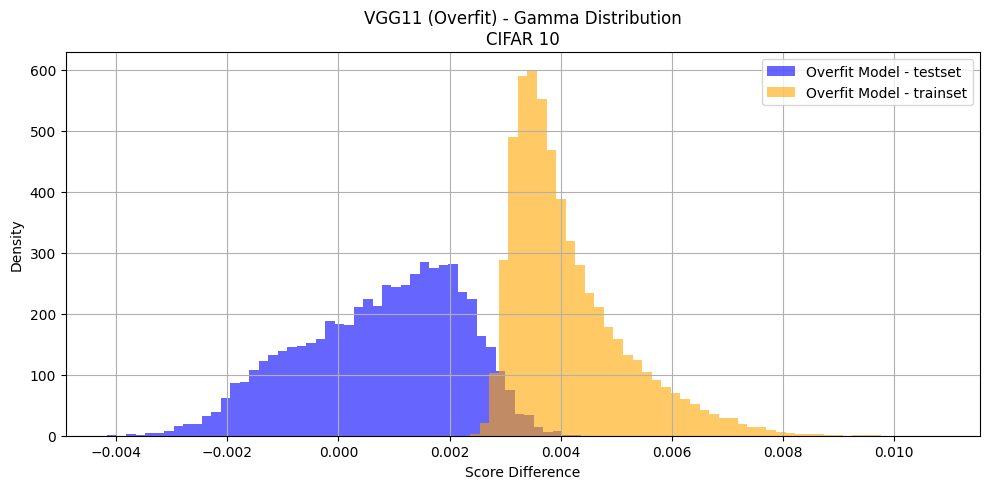

In [11]:
plt.figure(figsize=(10, 5))
# plt.hist(underfit, bins=50, alpha=0.6, label="Underfit Model", color="green", density=True)
plt.hist(overfit_test, bins=50, alpha=0.6, label="Overfit Model - testset", color="blue", density=True)
plt.hist(overfit_train, bins=50, alpha=0.6, label="Overfit Model - trainset", color="orange", density=True)
plt.xlabel("Score Difference")
plt.ylabel("Density")
plt.title(f"VGG11 (Overfit) - Gamma Distribution\nCIFAR 10")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gamma_hist_vgg11_cifar10_overfit.png")
plt.show()

In [12]:
correct_train = compute_gamma_distribution("ckpt_vgg11_cifar10/epoch_1000.pth", True)
correct_test = compute_gamma_distribution("ckpt_vgg11_cifar10/epoch_1000.pth", False)

Loading pretrained VGG11 model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d
Processing layer: features.4 of type Conv2d
Processing layer: features.8 of type Conv2d
Processing layer: features.11 of type Conv2d
Processing layer: features.15 of type Conv2d
Processing layer: features.18 of type Conv2d
Processing layer: features.22 of type Conv2d
Processing layer: features.25 of type Conv2d
Processing layer: classifier.0 of type Linear
Processing layer: classifier.3 of type Linear
Processing layer: classifier.6 of type Linear
Maximum Computation Time for Layer: 0.1037s
Total Computation Time: 0.1265s

--- Results ---
Product Component (Lipschitz-like term): 5.6950e+00
Summation Component (Structural Deviation term): 2.2600e+03
Total Spectral Complexity (R_A): 1.2871e+04


Eval: 100%|██████████| 391/391 [00:30<00:00, 12.81it/s]


Loading pretrained VGG11 model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d
Processing layer: features.4 of type Conv2d
Processing layer: features.8 of type Conv2d
Processing layer: features.11 of type Conv2d
Processing layer: features.15 of type Conv2d
Processing layer: features.18 of type Conv2d
Processing layer: features.22 of type Conv2d
Processing layer: features.25 of type Conv2d
Processing layer: classifier.0 of type Linear
Processing layer: classifier.3 of type Linear
Processing layer: classifier.6 of type Linear
Maximum Computation Time for Layer: 0.1009s
Total Computation Time: 0.1232s

--- Results ---
Product Component (Lipschitz-like term): 5.6950e+00
Summation Component (Structural Deviation term): 2.2600e+03
Total Spectral Complexity (R_A): 1.2871e+04


Eval: 100%|██████████| 79/79 [00:06<00:00, 12.94it/s]


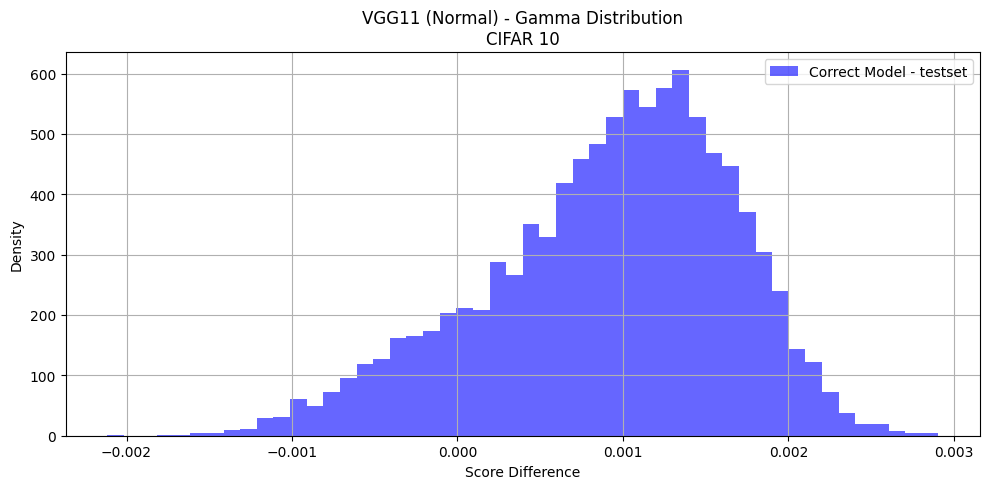

In [13]:
plt.figure(figsize=(10, 5))
# plt.hist(underfit, bins=50, alpha=0.6, label="Underfit Model", color="green", density=True)
plt.hist(correct_test, bins=50, alpha=0.6, label="Correct Model - testset", color="blue", density=True)
# plt.hist(overfit, bins=50, alpha=0.6, label="Overfit Model", color="orange", density=True)
plt.xlabel("Score Difference")
plt.ylabel("Density")
plt.title(f"VGG11 (Normal) - Gamma Distribution\nCIFAR 10")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig("gamma_hist_ResNet18_cifar10.png")
plt.show()

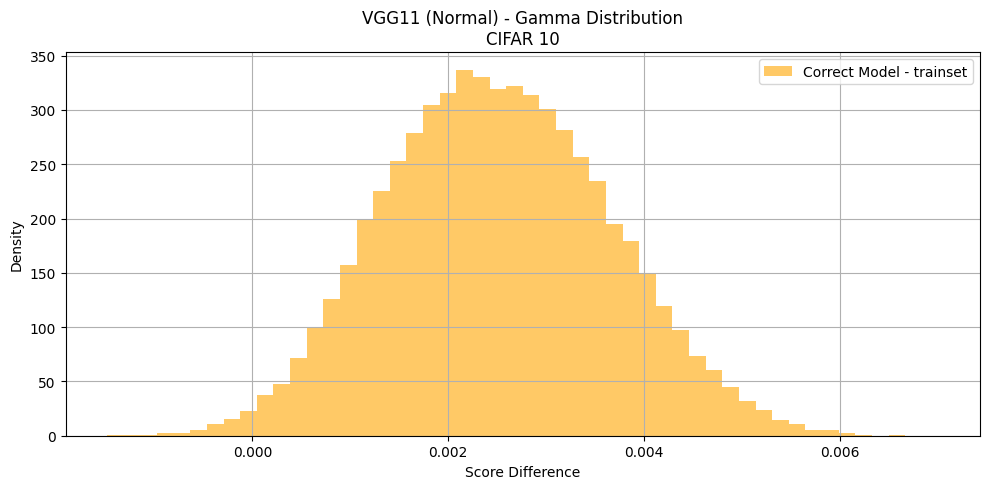

In [14]:
plt.figure(figsize=(10, 5))
# plt.hist(underfit, bins=50, alpha=0.6, label="Underfit Model", color="green", density=True)
# plt.hist(correct, bins=50, alpha=0.6, label="Correct Model", color="blue", density=True)
plt.hist(correct_train, bins=50, alpha=0.6, label="Correct Model - trainset", color="orange", density=True)
plt.xlabel("Score Difference")
plt.ylabel("Density")
plt.title(f"VGG11 (Normal) - Gamma Distribution\nCIFAR 10")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig("gamma_hist_ResNet18_cifar10.png")
plt.show()

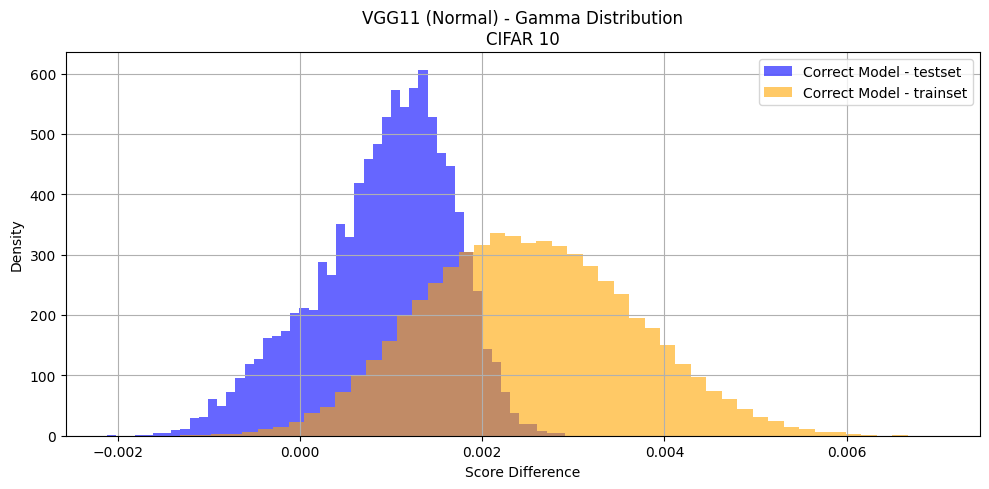

In [15]:
plt.figure(figsize=(10, 5))
# plt.hist(underfit, bins=50, alpha=0.6, label="Underfit Model", color="green", density=True)
plt.hist(correct_test, bins=50, alpha=0.6, label="Correct Model - testset", color="blue", density=True)
plt.hist(correct_train, bins=50, alpha=0.6, label="Correct Model - trainset", color="orange", density=True)
plt.xlabel("Score Difference")
plt.ylabel("Density")
plt.title(f"VGG11 (Normal) - Gamma Distribution\nCIFAR 10")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gamma_hist_vgg11_cifar10.png")
plt.show()

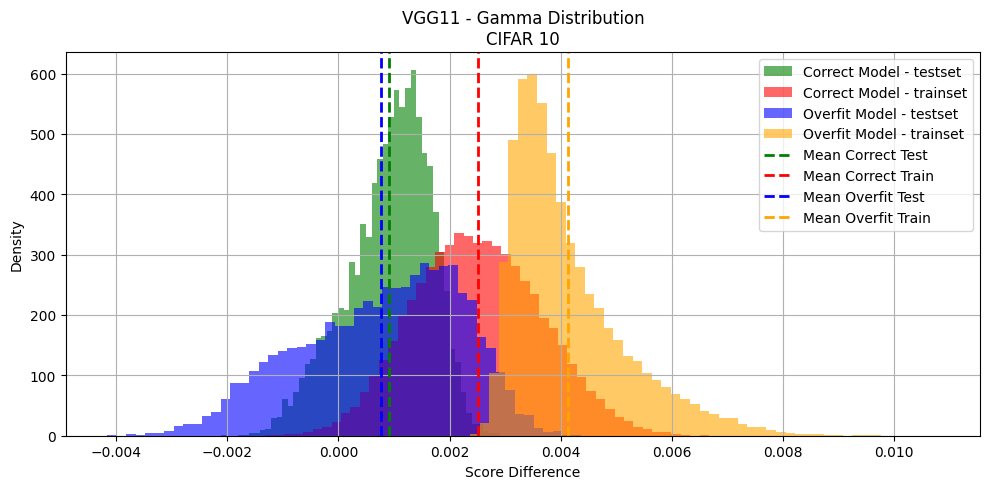

In [16]:
# print(type(overfit_train))
otr = np.mean(overfit_train)
ote = np.mean(overfit_test)
ctr = np.mean(correct_train)
cte = np.mean(correct_test)


plt.figure(figsize=(10, 5))
plt.hist(correct_test, bins=50, alpha=0.6, label="Correct Model - testset", color="green", density=True)
plt.hist(correct_train, bins=50, alpha=0.6, label="Correct Model - trainset", color="red", density=True)
plt.hist(overfit_test, bins=50, alpha=0.6, label="Overfit Model - testset", color="blue", density=True)
plt.hist(overfit_train, bins=50, alpha=0.6, label="Overfit Model - trainset", color="orange", density=True)

plt.axvline(cte, color='green', linestyle='dashed', linewidth=2, label='Mean Correct Test')
plt.axvline(ctr, color='red', linestyle='dashed', linewidth=2, label='Mean Correct Train')
plt.axvline(ote, color='blue', linestyle='dashed', linewidth=2, label='Mean Overfit Test')
plt.axvline(otr, color='orange', linestyle='dashed', linewidth=2, label='Mean Overfit Train')

plt.xlabel("Score Difference")
plt.ylabel("Density")
plt.title(f"VGG11 - Gamma Distribution\nCIFAR 10")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gamma_hist_vgg11_cifar10_all4.png")
plt.show()

In [18]:
subset_size = 512
overfit_test = compute_gamma_distribution("ckpt_vgg11_cifar10_overfit/epoch_1000.pth", False, subset_size)
correct_test = compute_gamma_distribution("ckpt_vgg11_cifar10/epoch_1000.pth", False)

Loading pretrained VGG11 model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d
Processing layer: features.4 of type Conv2d
Processing layer: features.8 of type Conv2d
Processing layer: features.11 of type Conv2d
Processing layer: features.15 of type Conv2d
Processing layer: features.18 of type Conv2d
Processing layer: features.22 of type Conv2d
Processing layer: features.25 of type Conv2d
Processing layer: classifier.0 of type Linear
Processing layer: classifier.3 of type Linear
Processing layer: classifier.6 of type Linear
Maximum Computation Time for Layer: 0.1038s
Total Computation Time: 0.1271s

--- Results ---
Product Component (Lipschitz-like term): 4.6059e+00
Summation Component (Structural Deviation term): 2.5395e+03
Total Spectral Complexity (R_A): 1.1697e+04
Testset size is: 10000


Eval: 100%|██████████| 4/4 [00:00<00:00, 11.45it/s]


Loading pretrained VGG11 model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d
Processing layer: features.4 of type Conv2d
Processing layer: features.8 of type Conv2d
Processing layer: features.11 of type Conv2d
Processing layer: features.15 of type Conv2d
Processing layer: features.18 of type Conv2d
Processing layer: features.22 of type Conv2d
Processing layer: features.25 of type Conv2d
Processing layer: classifier.0 of type Linear
Processing layer: classifier.3 of type Linear
Processing layer: classifier.6 of type Linear
Maximum Computation Time for Layer: 0.1010s
Total Computation Time: 0.1234s

--- Results ---
Product Component (Lipschitz-like term): 5.6950e+00
Summation Component (Structural Deviation term): 2.2600e+03
Total Spectral Complexity (R_A): 1.2871e+04


Eval: 100%|██████████| 79/79 [00:06<00:00, 12.85it/s]


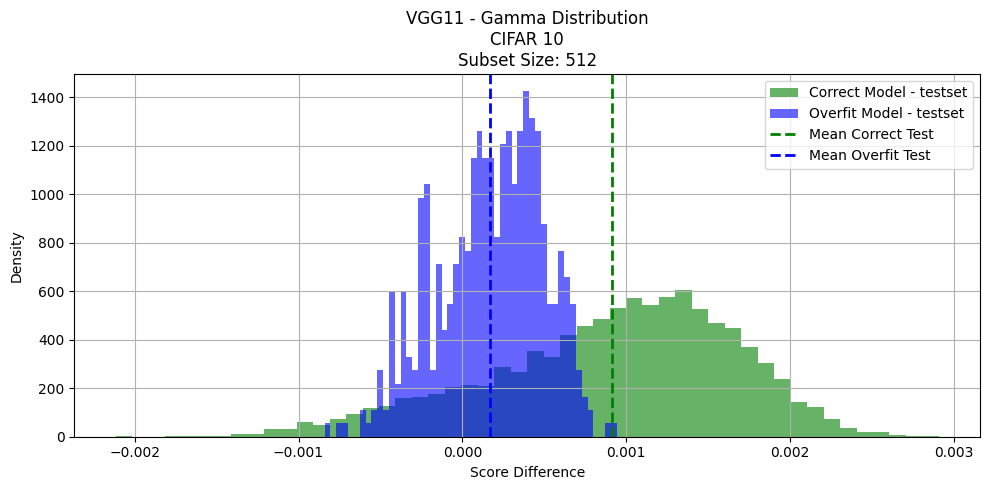

In [19]:
# print(type(overfit_train))
# otr = np.mean(overfit_train)
ote = np.mean(overfit_test)
# ctr = np.mean(correct_train)
cte = np.mean(correct_test)


plt.figure(figsize=(10, 5))
plt.hist(correct_test, bins=50, alpha=0.6, label="Correct Model - testset", color="green", density=True)
# plt.hist(correct_train, bins=50, alpha=0.6, label="Correct Model - trainset", color="red", density=True)
plt.hist(overfit_test, bins=50, alpha=0.6, label="Overfit Model - testset", color="blue", density=True)
# plt.hist(overfit_train, bins=50, alpha=0.6, label="Overfit Model - trainset", color="orange", density=True)

plt.axvline(cte, color='green', linestyle='dashed', linewidth=2, label='Mean Correct Test')
# plt.axvline(ctr, color='red', linestyle='dashed', linewidth=2, label='Mean Correct Train')
plt.axvline(ote, color='blue', linestyle='dashed', linewidth=2, label='Mean Overfit Test')
# plt.axvline(otr, color='orange', linestyle='dashed', linewidth=2, label='Mean Overfit Train')

plt.xlabel("Score Difference")
plt.ylabel("Density")
plt.title(f"VGG11 - Gamma Distribution\nCIFAR 10\nSubset Size: {subset_size}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"gamma_hist_vgg11_cifar10_subset_{subset_size}.png")
plt.show()

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # CIFAR-10 mean/std
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# subset_size = 5000
# remaining_size = len(trainset) - subset_size

# # Perform the random split
# trainset, _ = torch.utils.data.random_split(trainset, [subset_size, remaining_size])
trainloader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

In [2]:
class VGG11_Narrow(nn.Module):
    def __init__(self):
        super(VGG11_Narrow, self).__init__()
        
        # NOTE: All Conv layers are capped at 64 channels.
        self.features = nn.Sequential(
            # Block 1: 32x32 -> 16x16
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 2: 16x16 -> 8x8
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # Normally increases to 128
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 3: 8x8 -> 4x4
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # Normally 256
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 4: 4x4 -> 2x2
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # Normally 512
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 5: 2x2 -> 1x1
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # Normally 512
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        # Classifier: Feature map is 64 x 1 x 1
        self.classifier = nn.Sequential(
            nn.Linear(64, 1024),  # Input flattened from 64*1*1
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 10)   # 10 Classes for CIFAR-10
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Flatten (Batch_Size, 64)
        x = self.classifier(x)
        return x

In [4]:
# Load LeNet5
model = VGG11_Narrow()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.1, weight_decay=0)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200) # Optional: Learning rate scheduler

epochs = 1000 # Adjust as needed

train_acc = list()
test_acc = list()
train_loss = list()
test_loss = list()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    test_running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}, Train: ")
    for batch_idx, (inputs, targets) in enumerate(pbar):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
    train_acc_ = 100 * correct / total
    scheduler.step()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        pbar = tqdm(testloader, desc=f"Eval: ")
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    
    test_acc_ = 100 * correct / total
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}, train acc: {train_acc_:.2f}%, test acc: {test_acc_:.2f}%")
    train_acc.append(train_acc_)
    test_acc.append(test_acc_)
    train_loss.append(running_loss/len(trainloader))
    test_loss.append(test_running_loss/len(testloader))
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"ckpt_vgg11_cifar10_overfit/epoch_{epoch+1}.pth")

Eval: 100%|██████████| 79/79 [00:01<00:00, 67.28it/s]


Epoch 1, Loss: 2.2513, train acc: 15.29%, test acc: 23.62%


Eval: 100%|██████████| 79/79 [00:01<00:00, 60.05it/s]


Epoch 2, Loss: 1.9345, train acc: 25.88%, test acc: 34.07%


Eval: 100%|██████████| 79/79 [00:01<00:00, 69.46it/s]


...

Eval: 100%|██████████| 79/79 [00:01<00:00, 70.22it/s]


Epoch 941, Loss: 0.0001, train acc: 100.00%, test acc: 70.27%


Eval: 100%|██████████| 79/79 [00:01<00:00, 64.42it/s]


Epoch 942, Loss: 0.0001, train acc: 100.00%, test acc: 70.22%


Epoch 943/1000, Train:  58%|█████▊    | 57/98 [00:03<00:02, 17.02it/s]

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_acc, label="Train Accuracy")
plt.plot(range(1, epochs + 1), test_acc, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"VGG11 CIFAR10 Overfit Accuracy Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"vgg11_cifar10_overfit_accuracy_curve.png")
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss, label="Train Loss")
plt.plot(range(1, epochs + 1), test_loss, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"VGG11 CIFAR10 Overfit Loss Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"vgg11_cifar10_overfit_loss_curve.png")
plt.show()

In [ ]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # CIFAR-10 mean/std
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # CIFAR-10 mean/std
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

In [ ]:
# Load LeNet5
model = VGG11_Narrow()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.1, weight_decay=0)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200) # Optional: Learning rate scheduler

epochs = 1000 # Adjust as needed

train_acc = list()
test_acc = list()
train_loss = list()
test_loss = list()

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    test_running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}, Train: ")
    for batch_idx, (inputs, targets) in enumerate(pbar):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
    train_acc_ = 100 * correct / total
    scheduler.step()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        pbar = tqdm(testloader, desc=f"Eval: ")
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    
    test_acc_ = 100 * correct / total
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}, train acc: {train_acc_:.2f}%, test acc: {test_acc_:.2f}%")
    train_acc.append(train_acc_)
    test_acc.append(test_acc_)
    train_loss.append(running_loss/len(trainloader))
    test_loss.append(test_running_loss/len(testloader))
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"ckpt_vgg11_cifar10/epoch_{epoch+1}.pth")

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_acc, label="Train Accuracy")
plt.plot(range(1, epochs + 1), test_acc, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"VGG11 CIFAR10 Accuracy Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"vgg11_cifar10_accuracy_curve.png")
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss, label="Train Loss")
plt.plot(range(1, epochs + 1), test_loss, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"VGG11 CIFAR10 Loss Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"vgg11_cifar10_loss_curve.png")
plt.show()